In [1]:
! pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [2]:
! pip install imbalanced-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from imblearn.under_sampling import NearMiss

from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score, f1_score

In [2]:
data = pd.read_csv("diabetes_prediction_dataset.csv")
data

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [3]:
data.isna().sum()
data.info(memory_usage=True)

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


In [4]:
data["age"] = data["age"].astype("float32")
data["hypertension"] = data["hypertension"].astype("int8")
data["heart_disease"] = data["heart_disease"].astype("int8")
data["bmi"] = data["bmi"].astype("float32")
data["HbA1c_level"] = data["HbA1c_level"].astype("float32")
data["blood_glucose_level"] = data["blood_glucose_level"].astype("int8")
data["diabetes"] = data["diabetes"].astype("int8")

In [5]:
data["gender"] = (data["gender"] == "Female").astype("int8")

In [6]:
counts = data["smoking_history"].value_counts()
for v in counts.keys():
    data[f"smoking_history_{v}"] = (data["smoking_history"] == v).astype("int8")
data.drop("smoking_history", axis=1, inplace=True)

In [7]:
stat, p = stats.shapiro(data)
print(f'p-value: {p}')

p-value: 4.340542008993965e-208


/Users/david/Documents/ML/.venv/lib/python3.14/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 1400000.
  res = hypotest_fun_out(*samples, **kwds)


In [8]:
data

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_No Info,smoking_history_never,smoking_history_former,smoking_history_current,smoking_history_not current,smoking_history_ever
0,1,80.0,0,1,25.190001,6.6,-116,0,0,1,0,0,0,0
1,1,54.0,0,0,27.320000,6.6,80,0,1,0,0,0,0,0
2,0,28.0,0,0,27.320000,5.7,-98,0,0,1,0,0,0,0
3,1,36.0,0,0,23.450001,5.0,-101,0,0,0,0,1,0,0
4,0,76.0,1,1,20.139999,4.8,-101,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1,80.0,0,0,27.320000,6.2,90,0,1,0,0,0,0,0
99996,1,2.0,0,0,17.370001,6.5,100,0,1,0,0,0,0,0
99997,0,66.0,0,0,27.830000,5.7,-101,0,0,0,1,0,0,0
99998,1,24.0,0,0,35.419998,4.0,100,0,0,1,0,0,0,0


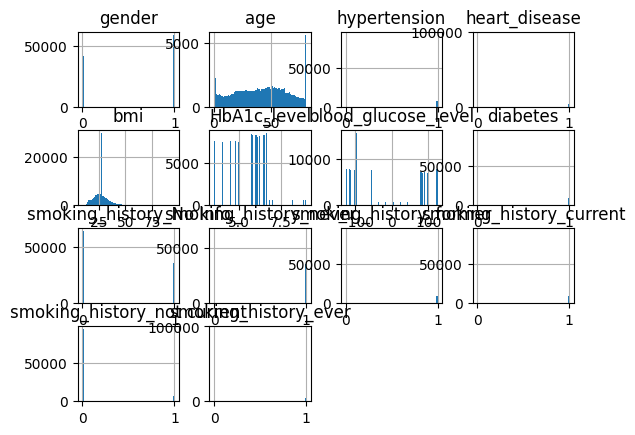

In [9]:
data.hist(bins=80);

In [10]:
y = data["diabetes"].values
x = data.drop("diabetes", axis=1).values

In [16]:
undersample = NearMiss(version=2, n_neighbors_ver3=3)
x, y = undersample.fit_resample(x, y)

In [14]:
# plt.hist(data, bins=80);
data.describe()

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_No Info,smoking_history_never,smoking_history_former,smoking_history_current,smoking_history_not current,smoking_history_ever
count,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.00000,100000.000000
mean,0.585520,41.885857,0.07485,0.039420,27.320768,5.527507,-26.176180,0.085000,0.358160,0.35095,0.093520,0.092860,0.06447,0.040040
std,0.492635,22.516840,0.26315,0.194593,6.636784,1.070672,95.639731,0.278883,0.479462,0.47727,0.291161,0.290238,0.24559,0.196054
min,0.000000,0.080000,0.00000,0.000000,10.010000,3.500000,-126.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000
25%,0.000000,24.000000,0.00000,0.000000,23.629999,4.800000,-101.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000
50%,1.000000,43.000000,0.00000,0.000000,27.320000,5.800000,-96.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000
75%,1.000000,60.000000,0.00000,0.000000,29.580000,6.200000,85.000000,0.000000,1.000000,1.00000,0.000000,0.000000,0.00000,0.000000
max,1.000000,80.000000,1.00000,1.000000,95.690002,9.000000,126.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.00000,1.000000


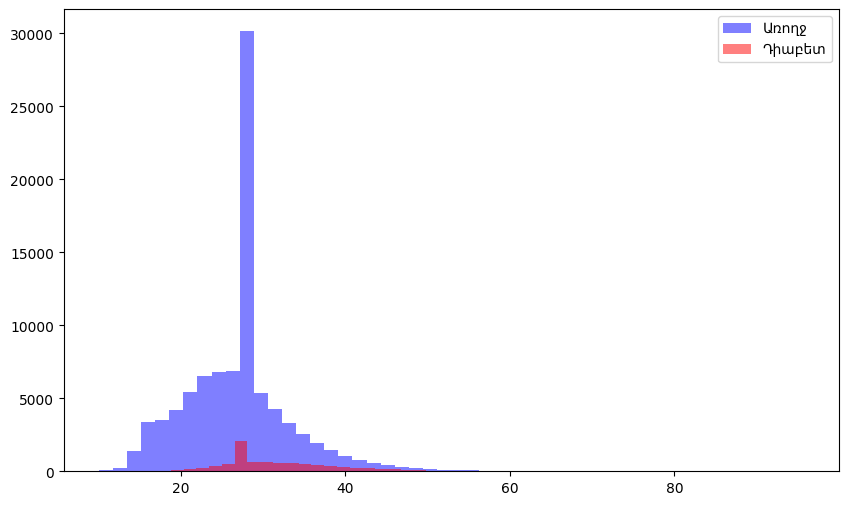

In [15]:
plt.figure(figsize=(10, 6))
plt.hist(data[data['diabetes'] == 0]['bmi'], bins=50, alpha=0.5, label='Առողջ', color='blue')
plt.hist(data[data['diabetes'] == 1]['bmi'], bins=50, alpha=0.5, label='Դիաբետ', color='red')
plt.legend()

In [17]:
scores_train = []
scores_test = []
scores_test_f1 = []
scores_train_f1 = []
cv = KFold(n_splits=5, shuffle=True, random_state=42)
for train_ind, test_ind in cv.split(x):
    x_train, x_test, y_train, y_test = x[train_ind], x[test_ind], y[train_ind], y[test_ind]
    sc = MinMaxScaler()
    x_train = sc.fit_transform(x_train)
    x_test = sc.transform(x_test)
    model = KNeighborsClassifier(n_neighbors=5, p=1)
    model.fit(x_train, y_train)
    acc_test = accuracy_score(y_test, model.predict(x_test))
    acc_train = accuracy_score(y_train, model.predict(x_train))
    f1_test = f1_score(y_test, model.predict(x_test))
    f1_train = f1_score(y_train, model.predict(x_train))
    scores_test.append(acc_test)
    scores_train.append(acc_train)
    scores_test_f1.append(f1_test)
    scores_train_f1.append(f1_train)
print(f"Scores_Train: {np.mean(scores_train)} \nScores_Test: {np.mean(scores_test)} \nF1_train: {np.mean(scores_train_f1)} \nF1_test: {np.mean(scores_test_f1)}")

Scores_Train: 0.96875 
Scores_Test: 0.9542352941176471 
F1_train: 0.968148941831936 
F1_test: 0.9531173706840989
